In [5]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load the state dataset
state = pd.read_csv(
    "https://spataru.at/campus02/state.csv"
)


def trimmed_mean(series: pd.Series, proportion_to_cut: float = 0.1) -> float:
    """Drop proportion_to_cut from each tail and compute the mean."""
    data = np.sort(series.to_numpy())
    n = len(data)
    k = int(n * proportion_to_cut)
    return data[k : n - k].mean()


def weighted_median(values: pd.Series, weights: pd.Series) -> float:
    """Weighted median where cumulative weight reaches 50%."""
    values = np.asarray(values)
    weights = np.asarray(weights)
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cum_w = np.cumsum(w)
    cutoff = 0.5 * w.sum()
    return v[np.searchsorted(cum_w, cutoff)]

# Center Location

1) Figure out the center of the population distribution: compute mean, 10% trimmed mean, and median.


In [6]:
pop = state.Population

In [7]:
pop.mean()

np.float64(6162876.3)

In [8]:
trimmed_mean(pop, 0.1)

np.float64(4783697.125)

In [9]:
pop.median()

np.float64(4436369.5)

2) Calculate the average murder rate for the country.


In [10]:
state["Murder.Rate"].mean()

np.float64(4.066)

3) Calculate the population-weighted mean and weighted median of murder rates.

In [11]:
murder = state["Murder.Rate"]
#np.average( for w_mean
np.average(murder, weights=pop)

np.float64(4.445833981123393)

weighted_median(murder, pop)

### Variability exercise
Compute the population variance, standard deviation, and median absolute deviation (MAD) of state populations.

In [12]:
print(pop.var())
print(pop.var())

46898327373394.445
46898327373394.445


In [13]:
pop_median = pop.median()

In [14]:
MAD = (pop - pop_median).abs().median()

 Order statistics exercise
1) Find the 10th, 50th, and 95th percentiles of state populations.
2) Identify which states sit at or above the 95th percentile threshold.



In [15]:
# Quantiles for population
#pop.quantile(target_quantiles)




### IQR exercise
Compute the interquartile range (IQR) of state populations (Q3 - Q1), and report Q1 and Q3 values.

### Boxplot (Plotly)
Interactive boxplot of state populations.

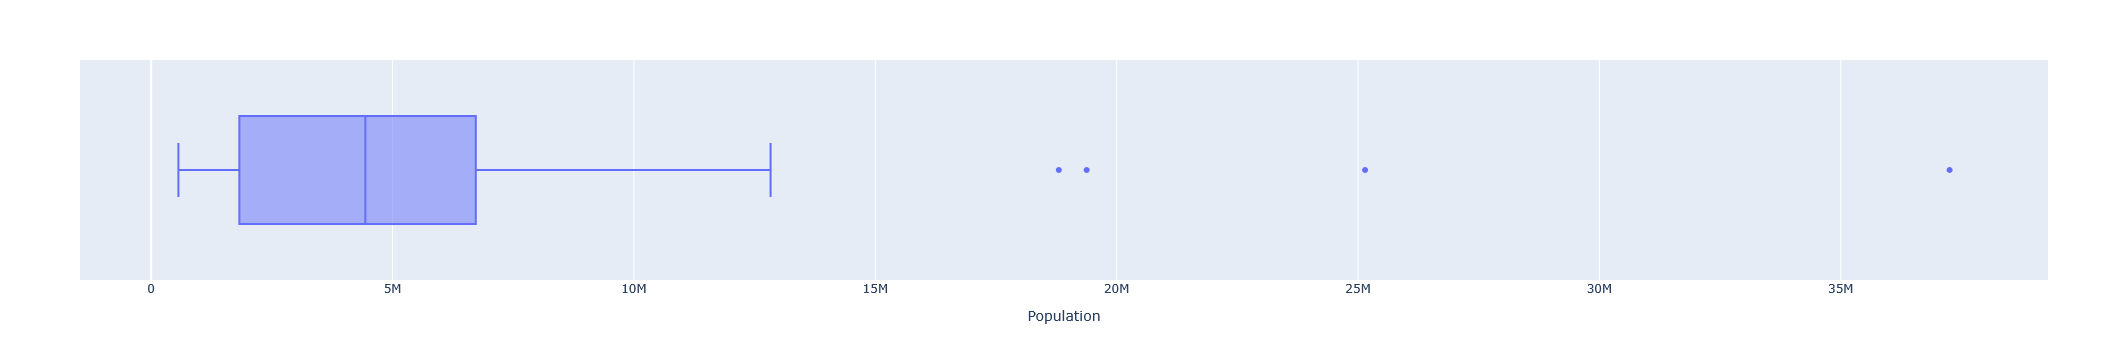

In [16]:
px.box(state, x="Population")

### Histogram (Plotly)
Distribution of state populations.

In [ ]:
px.histogram(state, x="Population")

### Violin plot (Plotly)
Distribution of state populations with density shape.

In [ ]:
px.violin(state, x="Population")

In [ ]:
x§